# 01 - Exploratory Data Analysis

**Goal:** Load DataCollector CSV, verify data quality, analyze feature distributions, check label balance, identify correlations.

**Tasks:**
- Load CSV and validate (no NaN/Inf)
- Check label balance (win/loss/timeout for both directions)
- Summary statistics for all features
- Feature correlation analysis
- Identify and document any data quality issues
- Drop dead/low-variance features if needed

In [6]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_datacollector_csv, get_data_splits, validate_data_quality
from src.labels import get_label_balance, print_label_summary
from src.features import get_feature_columns, check_feature_distributions, get_highly_correlated_features

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

%matplotlib inline

## 1. Load Data

In [7]:
# Load CSV
csv_path = '../data/DataCollector_EURUSD_M5_20230101_220400.csv'
df = load_datacollector_csv(csv_path)

print(f"Loaded {len(df):,} rows")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Loaded 243,216 rows
Columns: 45

First 5 rows:


,timestamp,symbol,dist_sma_m5_50,dist_sma_m5_100,dist_sma_m5_200,dist_sma_m5_275,dist_sma_m15_200,dist_sma_m30_200,dist_sma_h1_200,dist_sma_h4_200,slope_sma_m5_200,slope_sma_h1_200,rsi_m5,rsi_m15,rsi_m30,adx_m5,di_plus_m5,di_minus_m5,atr_m5,atr_m15,atr_h1,atr_ratio_m5_h1,bb_width,bar0_body,bar0_range,bar1_body,bar1_range,bar2_body,bar2_range,bar3_body,bar3_range,bar4_body,bar4_range,dist_swing_high,dist_swing_low,hour_utc,dow,sess_asia,sess_london,sess_ny,spread_pips,outcome_long,bars_to_outcome_long,outcome_short,bars_to_outcome_short
0,2023-01-02 06:15:00,EURUSD,0.351509,-0.023217,0.183068,1.821161,6.230464,9.642819,13.720000,48.938242,0.000087,0.00018,51.064084,50.447162,49.768704,26.666184,20.403320,32.535969,0.000431,0.000566,0.001694,0.254216,2.185462,-0.162521,0.580431,0.116086,1.184080,0.441128,1.044776,-0.301824,0.766169,0.139303,0.650083,1.996683,2.971808,6.0,1.0,1.0,0.0,0.0,1.0,loss,8,win,8
1,2023-01-02 06:20:00,EURUSD,0.347042,0.000246,0.149243,1.892151,6.614384,10.237007,14.565423,51.953803,0.000092,0.00018,51.064084,50.447162,49.768704,26.398460,19.794383,31.564933,0.000406,0.000566,0.001694,0.239460,2.226352,0.000000,0.345070,-0.172535,0.616197,0.123239,1.257042,0.468310,1.109155,-0.320423,0.813380,2.119718,3.154930,6.0,1.0,1.0,0.0,0.0,1.0,loss,7,win,7
2,2023-01-02 06:25:00,EURUSD,0.219893,-0.093166,0.011145,1.775170,6.528658,10.242290,14.699750,52.690089,0.000093,0.00018,49.694862,49.342911,51.537979,26.149858,18.679409,29.786949,0.000399,0.000571,0.001694,0.235666,2.136630,-0.100179,0.651163,0.000000,0.350626,-0.175313,0.626118,0.125224,1.277281,0.475850,1.127013,2.254025,3.105546,6.0,1.0,1.0,0.0,0.0,1.0,loss,6,win,6
3,2023-01-02 06:30:00,EURUSD,0.170824,-0.079529,-0.027059,1.623444,6.133647,9.622588,13.810353,49.502118,0.000090,0.00018,49.694862,49.342911,51.537979,25.515775,19.342753,27.419928,0.000425,0.000571,0.001694,0.250843,1.867536,0.047059,0.870588,-0.094118,0.611765,0.000000,0.329412,-0.164706,0.588235,0.117647,1.200000,2.117647,2.917647,6.0,1.0,1.0,0.0,0.0,1.0,loss,5,win,5
4,2023-01-02 06:35:00,EURUSD,0.224479,-0.008615,0.009932,1.678085,6.310291,9.858872,14.118222,50.420103,0.000082,0.00018,50.841400,49.342911,51.537979,24.926984,18.446771,26.149802,0.000418,0.000571,0.001694,0.246627,1.786338,0.095726,0.502564,0.047863,0.885470,-0.095726,0.622222,0.000000,0.335043,-0.167521,0.598291,2.082051,3.039316,6.0,1.0,1.0,0.0,0.0,1.0,loss,4,win,4


## 2. Data Quality Validation

In [8]:
# Run quality checks
quality_results = validate_data_quality(df, verbose=True)

Data quality check:
  Total rows: 243,216
  NaN values: 0
  Inf values: 0
  Duplicate timestamps: 0
  Status: ✓ PASSED


## 3. Data Splits

Split into train/CV, held-out test, and live forward sets per PRD.

In [9]:
# Split data
train_cv, held_out_test, live_forward = get_data_splits(df)

print(f"Train/CV:        {len(train_cv):7,} rows ({len(train_cv)/len(df)*100:5.1f}%)")
print(f"Held-out test:   {len(held_out_test):7,} rows ({len(held_out_test)/len(df)*100:5.1f}%)")
print(f"Live forward:    {len(live_forward):7,} rows ({len(live_forward)/len(df)*100:5.1f}%)")
print(f"\n⚠️  CRITICAL: Held-out test set must NOT be used for hyperparameter tuning!")

Train/CV:        204,105 rows ( 83.9%)
Held-out test:    36,845 rows ( 15.1%)
Live forward:      2,266 rows (  0.9%)

⚠️  CRITICAL: Held-out test set must NOT be used for hyperparameter tuning!


## 4. Label Balance Analysis

In [10]:
# Print label summary for train/CV set
print("\nTrain/CV set:")
print_label_summary(train_cv)


Train/CV set:

=== Label Balance Summary ===

LONG:
  Win:     62,108 ( 30.4%)
  Loss:    131,384 ( 64.4%)
  Timeout: 10,613 (  5.2%)
  Total:   204,105

SHORT:
  Win:     62,548 ( 30.6%)
  Loss:    130,550 ( 64.0%)
  Timeout: 11,007 (  5.4%)
  Total:   204,105


## 5. Feature Analysis

In [11]:
# Get feature columns
features = get_feature_columns(df)
print(f"Found {len(features)} features:")
for i, f in enumerate(features, 1):
    print(f"  {i:2d}. {f}")

Found 39 features:
   1. dist_sma_m5_50
   2. dist_sma_m5_100
   3. dist_sma_m5_200
   4. dist_sma_m5_275
   5. dist_sma_m15_200
   6. dist_sma_m30_200
   7. dist_sma_h1_200
   8. dist_sma_h4_200
   9. slope_sma_m5_200
  10. slope_sma_h1_200
  11. rsi_m5
  12. rsi_m15
  13. rsi_m30
  14. adx_m5
  15. di_plus_m5
  16. di_minus_m5
  17. atr_m5
  18. atr_m15
  19. atr_h1
  20. atr_ratio_m5_h1
  21. bb_width
  22. bar0_body
  23. bar0_range
  24. bar1_body
  25. bar1_range
  26. bar2_body
  27. bar2_range
  28. bar3_body
  29. bar3_range
  30. bar4_body
  31. bar4_range
  32. dist_swing_high
  33. dist_swing_low
  34. hour_utc
  35. dow
  36. sess_asia
  37. sess_london
  38. sess_ny
  39. spread_pips


In [12]:
# Feature distributions
feature_stats = check_feature_distributions(train_cv, features)
feature_stats

,count,mean,std,min,25%,50%,75%,max,nan_count,inf_count
dist_sma_m5_50,204105.0,0.086297,2.690152,-27.255351,-1.735895,0.086697,1.902146,27.705641,0,0
dist_sma_m5_100,204105.0,0.147642,4.370668,-43.295000,-2.548824,0.136651,2.848942,31.682464,0,0
dist_sma_m5_200,204105.0,0.164933,7.586685,-76.708074,-3.848975,0.194688,4.180245,60.604519,0,0
dist_sma_m5_275,204105.0,0.168107,9.517630,-88.932902,-4.651064,0.186358,5.030379,77.027657,0,0
dist_sma_m15_200,204105.0,0.285769,14.690836,-103.296290,-7.394642,0.212690,7.738712,116.370000,0,0
dist_sma_m30_200,204105.0,0.559797,20.614729,-179.530000,-10.162237,0.283163,11.110584,184.993333,0,0
dist_sma_h1_200,204105.0,1.401020,29.277143,-187.607913,-14.884977,0.314730,17.191556,268.813333,0,0
dist_sma_h4_200,204105.0,6.742510,60.079830,-477.910781,-28.070860,8.203238,39.716324,459.463333,0,0
slope_sma_m5_200,204105.0,0.000002,0.000096,-0.000551,-0.000052,0.000002,0.000054,0.000681,0,0
slope_sma_h1_200,204105.0,0.000030,0.000310,-0.000913,-0.000193,0.000012,0.000221,0.001358,0,0


## 6. Correlation Analysis

In [13]:
# Check for highly correlated features (>0.95)
high_corr = get_highly_correlated_features(train_cv, features, threshold=0.95)

if high_corr:
    print(f"Found {len(high_corr)} highly correlated feature pairs (>0.95):")
    for f1, f2, corr in high_corr:
        print(f"  {f1} <-> {f2}: {corr:.3f}")
else:
    print("No highly correlated feature pairs found (threshold: 0.95)")

Found 1 highly correlated feature pairs (>0.95):
  dist_sma_m5_275 <-> dist_sma_m5_200: 0.957


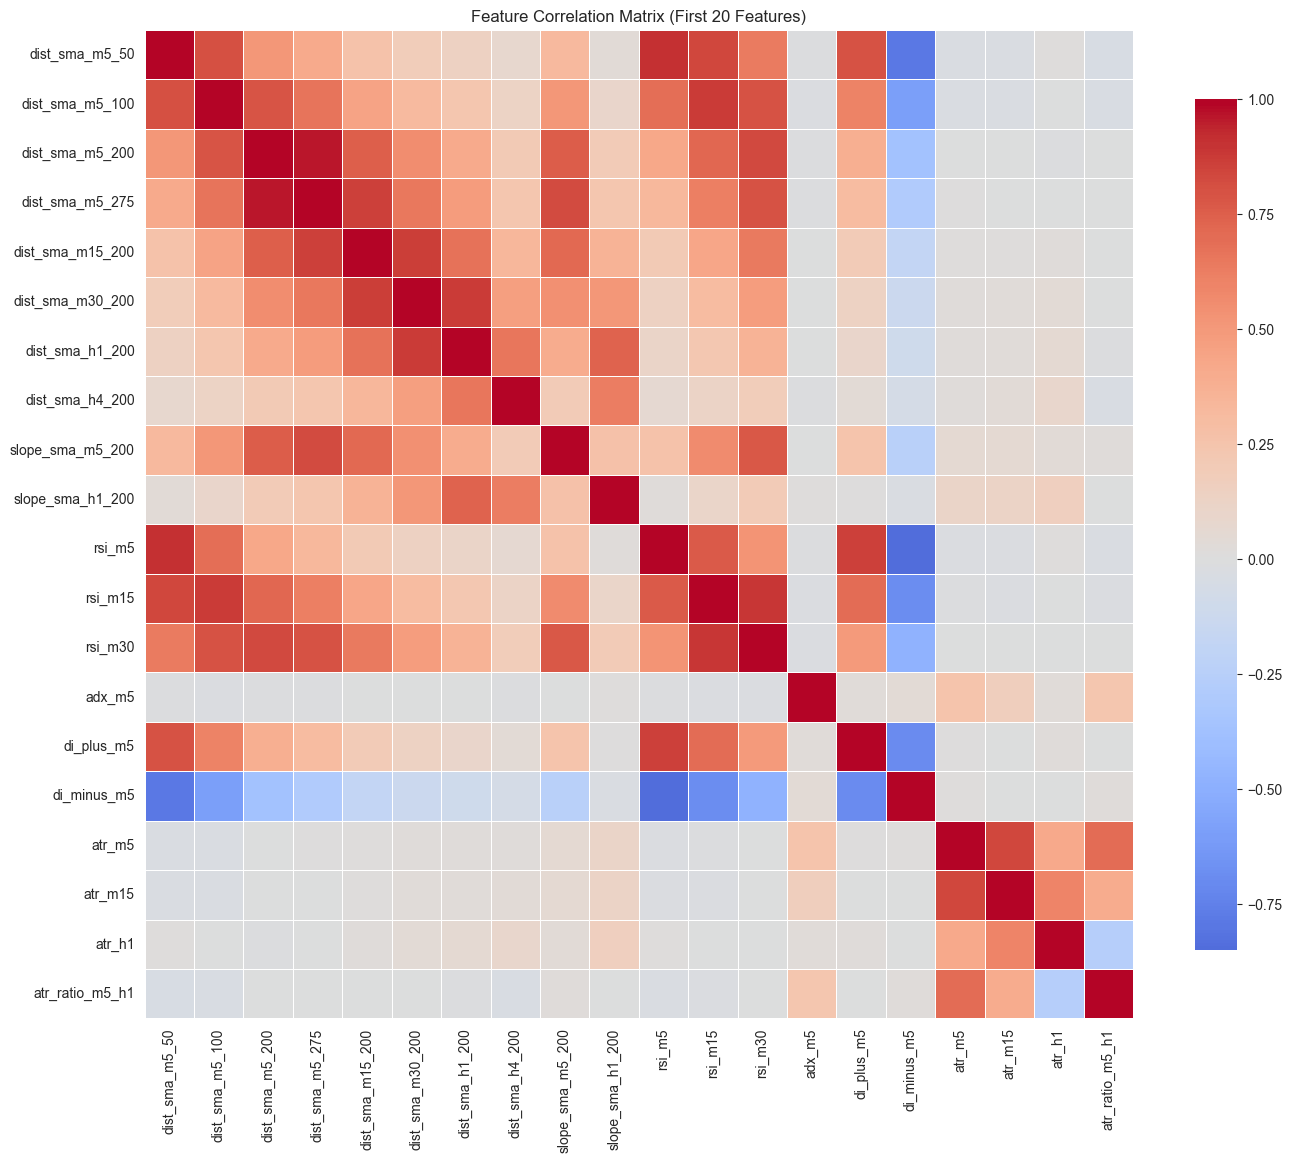

In [14]:
# Correlation heatmap (sample of features)
sample_features = features[:20]  # First 20 features
corr_matrix = train_cv[sample_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix (First 20 Features)')
plt.tight_layout()
plt.show()

## 7. Summary & Next Steps

**Data Quality:** ✓ PASSED / ✗ ISSUES FOUND

**Label Balance:** Document win/loss/timeout percentages

**Features:** Document any issues or features to drop

**Ready for modeling:** YES / NO